In [1]:
import torch
from diffusion.training.classifier_trainer import ClassifierTrainer
from diffusion.training.encoder_trainer import EncoderTrainer
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg
from diffusion.sampleables.whar_sampleable import WHARSampleable, TrainValTest
from diffusion.architectures.classifiers.wisdm_classifier import WISDMClassifier
from diffusion.sampleables.whar_sampleable import stft_transform_combine

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_dataset_cfg(WHARDatasetID.WISDM)
transform = lambda x: stft_transform_combine(x, n_fft=32, hop_length=1)  # type: ignore
scv_group_index = 0

2025-10-24 13:13:32,881 - whar-datasets - INFO - Running DownloadingStep
2025-10-24 13:13:32,881 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-24 13:13:32,882 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:32,882 - whar-datasets - INFO - Running ParsingStep
2025-10-24 13:13:32,883 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-24 13:13:32,883 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:32,884 - whar-datasets - INFO - Running WindowingStep
2025-10-24 13:13:32,884 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-24 13:13:32,885 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:32,885 - whar-datasets - INFO - Loading windowing
2025-10-24 13:13:32,947 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-24 13:13:32,948 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-24 13:13:32,950 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-24 13:13:32,951 - whar-datasets - INFO - R

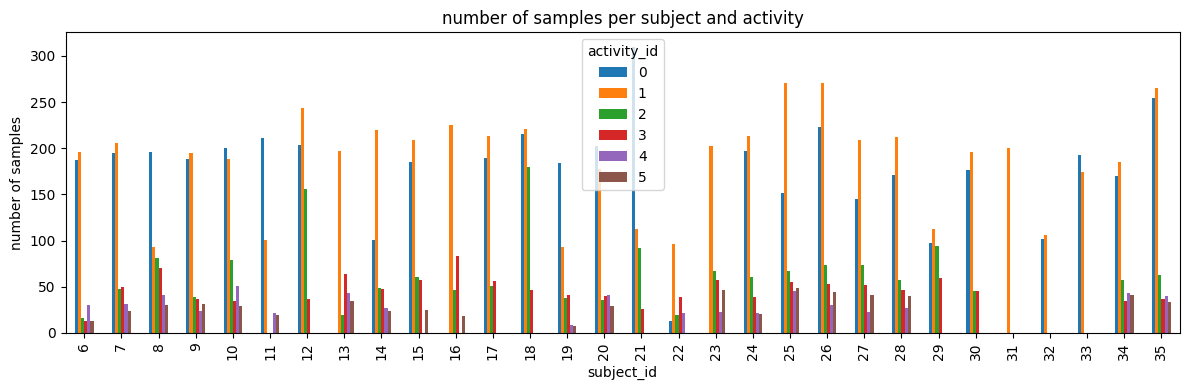

2025-10-24 13:13:35,664 - whar-datasets - INFO - Running DownloadingStep
2025-10-24 13:13:35,664 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-24 13:13:35,665 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:35,665 - whar-datasets - INFO - Running ParsingStep
2025-10-24 13:13:35,666 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-24 13:13:35,666 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:35,667 - whar-datasets - INFO - Running WindowingStep
2025-10-24 13:13:35,667 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-24 13:13:35,667 - whar-datasets - INFO - Hash is up to date
2025-10-24 13:13:35,668 - whar-datasets - INFO - Loading windowing
2025-10-24 13:13:35,686 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-24 13:13:35,687 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-24 13:13:35,693 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-24 13:13:35,695 - whar-datasets - INFO - R

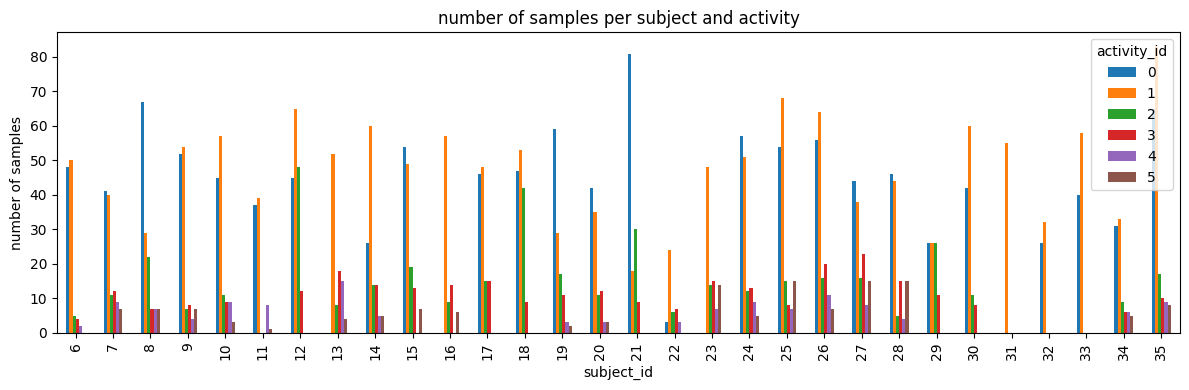

(100, 3)
(6, 17, 101)
6


In [4]:
sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.TRAIN,
    transform=transform,
)

val_sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.VAL,
    transform=transform,
)

print(sampeable.signal_shape)
print(sampeable.shape)
print(sampeable.num_classes)

In [5]:
classifier = WISDMClassifier(
    in_c=sampeable.shape[0], num_classes=sampeable.num_classes, size=6400
).to(device)

trainer = ClassifierTrainer(
    classifier=classifier,
    train_data=sampeable,
    val_data=val_sampeable,
    num_classes=sampeable.num_classes,
)

# trainer = EncoderTrainer(
#     encoder=classifier,
#     train_data=sampeable,
#     val_data=val_sampeable,
#     num_classes=sampeable.num_classes,
# )

2025-10-24 13:13:38,050 - flow-matching - INFO - Training model with size: 3.206 MiB
Epoch 0/15: 100%|██████████| 500/500 [00:22<00:00, 22.47it/s, train_loss=0.576326]


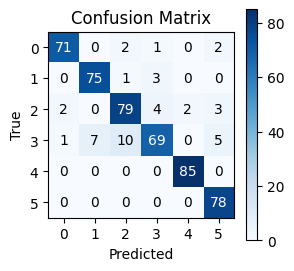

2025-10-24 13:14:00,865 - flow-matching - INFO - val loss: 0.9139999747276306, best val loss: 0.9139999747276306
Epoch 1/15: 100%|██████████| 500/500 [00:22<00:00, 22.63it/s, train_loss=0.197236]


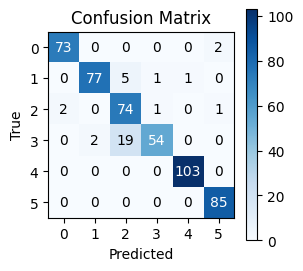

2025-10-24 13:14:23,502 - flow-matching - INFO - val loss: 0.9319999814033508, best val loss: 0.9319999814033508
Epoch 2/15: 100%|██████████| 500/500 [00:22<00:00, 22.66it/s, train_loss=0.094745]


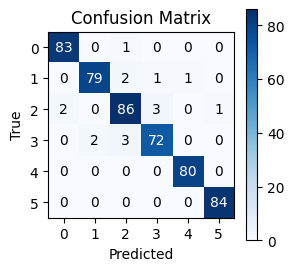

2025-10-24 13:14:46,092 - flow-matching - INFO - val loss: 0.9679999947547913, best val loss: 0.9679999947547913
Epoch 3/15: 100%|██████████| 500/500 [00:22<00:00, 22.52it/s, train_loss=0.054111]


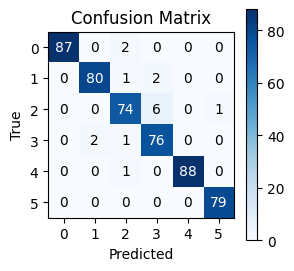

2025-10-24 13:15:08,816 - flow-matching - INFO - val loss: 0.9679999947547913, best val loss: 0.9679999947547913
Epoch 4/15: 100%|██████████| 500/500 [00:22<00:00, 22.56it/s, train_loss=0.036117]


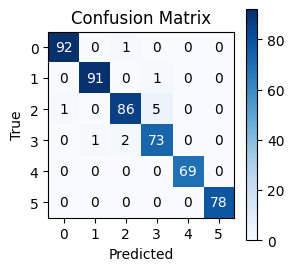

2025-10-24 13:15:31,502 - flow-matching - INFO - val loss: 0.9779999852180481, best val loss: 0.9779999852180481
Epoch 5/15: 100%|██████████| 500/500 [00:22<00:00, 22.51it/s, train_loss=0.025779]


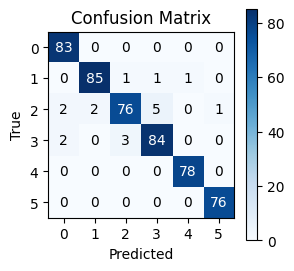

2025-10-24 13:15:54,233 - flow-matching - INFO - val loss: 0.9639999866485596, best val loss: 0.9779999852180481
Epoch 6/15: 100%|██████████| 500/500 [00:22<00:00, 22.50it/s, train_loss=0.021747]


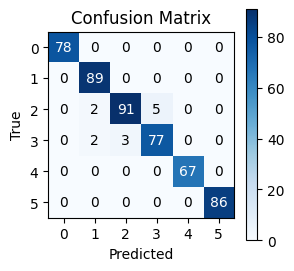

2025-10-24 13:16:16,989 - flow-matching - INFO - val loss: 0.9760000109672546, best val loss: 0.9779999852180481
Epoch 7/15: 100%|██████████| 500/500 [00:22<00:00, 22.30it/s, train_loss=0.019795]


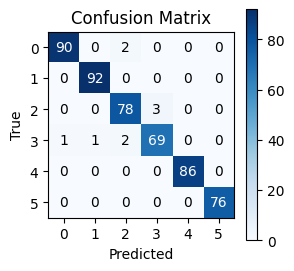

2025-10-24 13:16:39,944 - flow-matching - INFO - val loss: 0.9819999933242798, best val loss: 0.9819999933242798
Epoch 8/15: 100%|██████████| 500/500 [00:22<00:00, 22.67it/s, train_loss=0.016327]


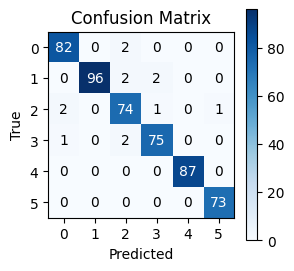

2025-10-24 13:17:02,533 - flow-matching - INFO - val loss: 0.9739999771118164, best val loss: 0.9819999933242798
Epoch 9/15: 100%|██████████| 500/500 [00:22<00:00, 22.61it/s, train_loss=0.014163]


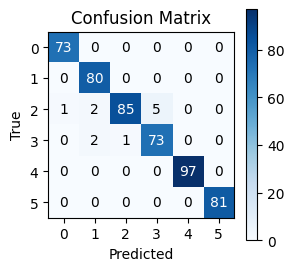

2025-10-24 13:17:25,168 - flow-matching - INFO - val loss: 0.9779999852180481, best val loss: 0.9819999933242798
Epoch 10/15: 100%|██████████| 500/500 [00:21<00:00, 22.74it/s, train_loss=0.011548]


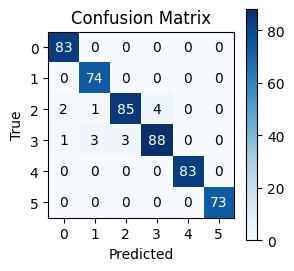

2025-10-24 13:17:47,699 - flow-matching - INFO - val loss: 0.972000002861023, best val loss: 0.9819999933242798
Epoch 11/15: 100%|██████████| 500/500 [00:22<00:00, 22.65it/s, train_loss=0.013563]


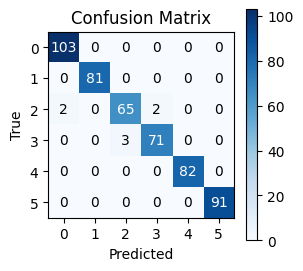

2025-10-24 13:18:10,282 - flow-matching - INFO - val loss: 0.9860000014305115, best val loss: 0.9860000014305115
Epoch 12/15: 100%|██████████| 500/500 [00:22<00:00, 22.65it/s, train_loss=0.007977]


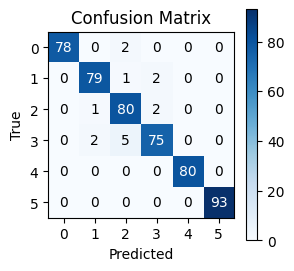

2025-10-24 13:18:32,878 - flow-matching - INFO - val loss: 0.9700000286102295, best val loss: 0.9860000014305115
Epoch 13/15: 100%|██████████| 500/500 [00:22<00:00, 22.64it/s, train_loss=0.007106]


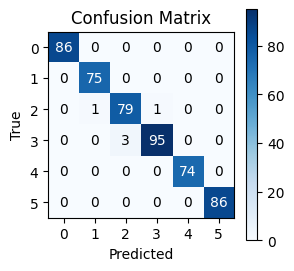

2025-10-24 13:18:55,489 - flow-matching - INFO - val loss: 0.9900000095367432, best val loss: 0.9900000095367432
Epoch 14/15: 100%|██████████| 500/500 [00:22<00:00, 22.57it/s, train_loss=0.017086]


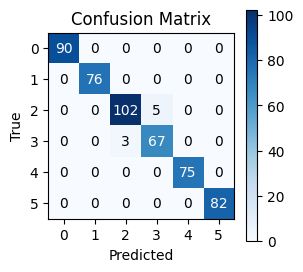

2025-10-24 13:19:18,164 - flow-matching - INFO - val loss: 0.984000027179718, best val loss: 0.9900000095367432


In [6]:
state_dict = trainer.train(
    num_epochs=15,
    device=device,
    lr=3e-4,
    batch_size=64,
    steps_per_epoch=500,
    validate=True,
    patience=5,
    decreasing=False,
    val_batch_size=500,
)

In [8]:
torch.save(classifier.state_dict(), "./models/classifier.pt")